In [37]:
# IMPORT ALL THINGS POSSIABLY NEEDED 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.tree import DecisionTreeClassifier

In [14]:
# Run of data
df = pd.read_csv("data/blood_cell_anomaly_detection.csv")
print("Head!")
print(df.head())
print()

print("Describe!")
print(df.describe())
print()

# Target Column 
print("=====================")
print("I pick Anomaly Label!")
print("=====================")

Head!
       cell_id                  cell_type  anomaly_label disease_category  \
0  CELL_005371  Hypersegmented_Neutrophil              1        Infection   
1  CELL_005300  Hypersegmented_Neutrophil              1        Infection   
2  CELL_000200                 Neutrophil              0       Normal_WBC   
3  CELL_003269                 Normal_RBC              0       Normal_RBC   
4  CELL_003505                 Normal_RBC              0       Normal_RBC   

   cell_diameter_um  nucleus_area_pct  chromatin_density  cytoplasm_ratio  \
0             15.18              58.8              0.542            0.301   
1             16.47              73.6              0.583            0.365   
2             13.41              55.5              0.448            0.376   
3              7.36               0.0              0.000            1.000   
4              7.53               0.0              0.000            1.000   

   circularity  eccentricity  ...  mcv_fl  mchc_g_dl  dataset_source

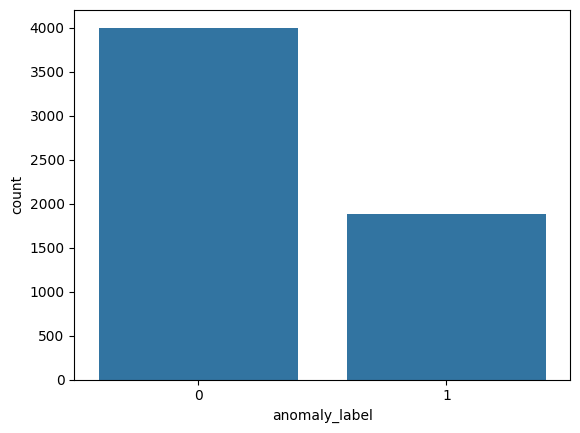

cell_id                                    0
cell_type                                  0
anomaly_label                              0
disease_category                           0
cell_diameter_um                           0
nucleus_area_pct                           0
chromatin_density                          0
cytoplasm_ratio                            0
circularity                                0
eccentricity                               0
granularity_score                          0
lobularity_score                           0
membrane_smoothness                        0
cell_area_px                               0
perimeter_px                               0
mean_r                                     0
mean_g                                     0
mean_b                                     0
stain_intensity                            0
patient_age_group                          0
patient_sex                                0
wbc_count_per_ul                           0
rbc_count_

In [16]:
# Distribution
df["anomaly_label"].value_counts()
sns.countplot(x = "anomaly_label", data = df)
plt.show()

# Missing Values
df.isnull().sum()

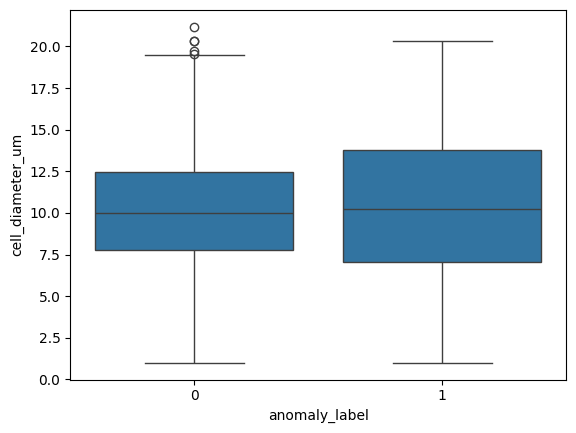

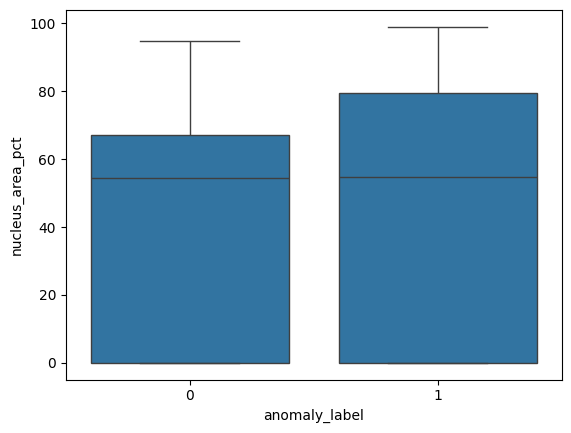

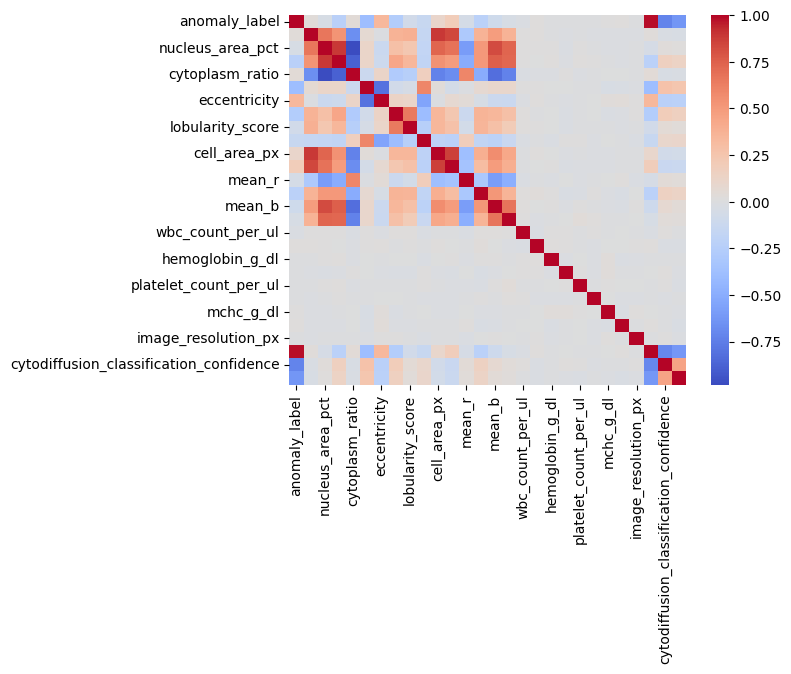

In [17]:
# Easy Visuals and Correlation
sns.boxplot(x = "anomaly_label", y = "cell_diameter_um", data = df)
plt.show()

sns.boxplot(x = "anomaly_label", y = "nucleus_area_pct", data = df)
plt.show()

sns.heatmap(df.corr(numeric_only = True), cmap = "coolwarm")
plt.show()

The dataset shows a difference in the number of normal and abnormal cells, with normal cells appearing more frequently, which may affect how the model learns patterns. There are no missing values in the dataset, meaning all features are complete and can be used without additional cleaning. The visualizations show some separation between normal and abnormal cells in features like cell diameter and nucleus area, suggesting that these measurements may help the model distinguish between the two groups.

In [26]:
# Step 3

#Size Ratio
df["size_ratio"] = df["cell_diameter_um"] / (df["nucleus_area_pct"] + 1)

#Density
df["density"] = df["hemoglobin_g_dl"] / df["cell_diameter_um"]

# Shape Index
df["shape_index"] = df["circularity"] * df["cell_diameter_um"]

#Check
print(df.head())

   anomaly_label  cell_diameter_um  nucleus_area_pct  chromatin_density  \
0              1             15.18              58.8              0.542   
1              1             16.47              73.6              0.583   
2              0             13.41              55.5              0.448   
3              0              7.36               0.0              0.000   
4              0              7.53               0.0              0.000   

   cytoplasm_ratio  circularity  eccentricity  granularity_score  \
0            0.301        0.563         0.529               4.11   
1            0.365        0.859         0.443               2.50   
2            0.376        0.781         0.407               3.01   
3            1.000        0.880         0.167               0.43   
4            1.000        1.000         0.158               0.51   

   lobularity_score  membrane_smoothness  ...  mcv_fl  mchc_g_dl  \
0               6.6                0.800  ...    85.5       31.4   
1   

FEATURE 1

Feature name and calculation: The size ratio feature was created by dividing cell diameter by nucleus area. This combines two measurements into one value that reflects how large the cell is compared to the size of its nucleus.

Why it should help: This feature helps capture the relationship between overall cell size and nucleus size, which may not be as clear when looking at each feature separately. Abnormal cells often show changes in this balance.

Domain justification: In biology, changes in the size of the nucleus compared to the rest of the cell are commonly used as indicators of abnormal cell behavior, especially in disease conditions.

Feature 2

Feature name and calculation: The density feature was created by dividing hemoglobin by cell diameter. This gives a measure of how concentrated hemoglobin is relative to the size of the cell.

Why it should help: This feature may highlight differences in how much hemoglobin is present in cells of different sizes, which may not be obvious when looking at each variable on its own.

Domain justification: Hemoglobin levels are important for understanding blood cell function, and abnormal levels can be linked to disease, making this a useful feature for identifying abnormal cells.

Feature 3

Feature name and calculation: The shape index feature was created by multiplying circularity by cell diameter. This combines shape and size into a single value.

Why it should help: This feature captures both how round a cell is and how large it is, which may help separate normal cells from abnormal ones more clearly.

Domain justification: Abnormal cells often show irregular shapes and changes in size, so combining these two characteristics can help better represent those changes.

In [23]:
# Dropping all non Numberical Columns
df = df.drop(columns=["cell_id", "dataset_source", "cell_type", "disease_category", "patient_age_group", "patient_sex", "staining_protocol", "microscope_model"])

In [31]:
# Step 4

# Split feature 
X = df.drop("anomaly_label", axis=1)
y = df["anomaly_label"]

# Train 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# Scale
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

The data was split into training and test sets using an 80/20 split, with stratification applied to maintain the balance between normal and abnormal cells. There were no missing values in the dataset, but rows with non numerical values from feature calculations were removed to make sure the data was clean. All numerical features were scaled using StandardScaler so that differences in measurement size did not affect model performance.

In [32]:
# Step 5

rf = RandomForestClassifier(n_estimators = 100, random_state = 42)

rf.fit(X_train, y_train)

# Predicitions
y_pred_rf = rf.predict(X_test)

# Accuracy
accuracy_score(y_test, y_pred_rf)

# Full report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       800
           1       1.00      1.00      1.00       376

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



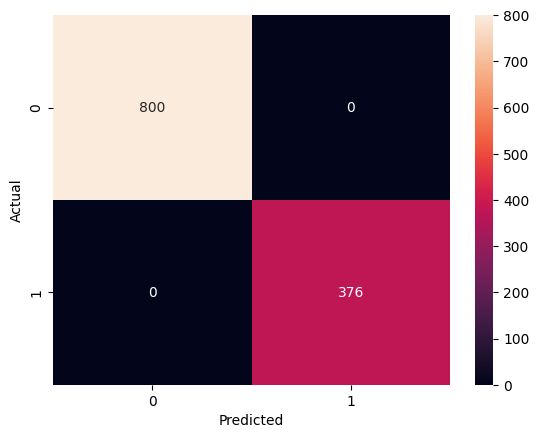

In [34]:
# Heat Map
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot = True, fmt = "d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

A Random Forest model was used to classify normal and abnormal cells based on the features in the dataset. The model was trained on the training data and test data, where it showed very strong performance with correct predictions for both classes. The results suggest that the features used in this dataset clearly separate normal and abnormal cells, allowing the model to classify them with high accuracy.

In [38]:
# Step 6

# Train Model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Predict
y_pred_dt = dt.predict(X_test)

# Accarte
accuracy_score(y_test, y_pred_dt)

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       800
           1       1.00      1.00      1.00       376

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



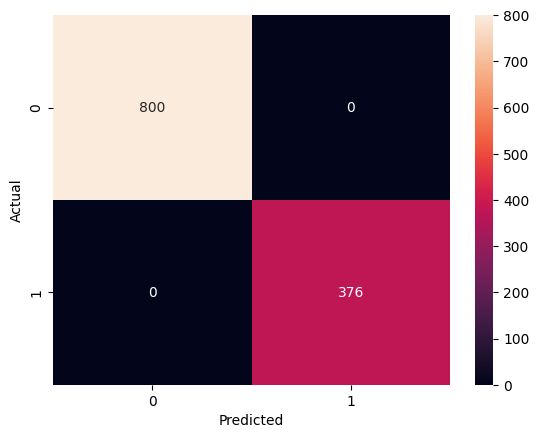

In [ ]:
# Heat Confusion Map
cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm, annot = True, fmt = "d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

A Decision Tree model was used as a second approach to classify normal and abnormal cells. The model was trained and tested using the same data split as the Random Forest model. The results showed that the model produced the same performance, correctly classifying all samples and suggested that the patterns in the dataset are clear enough that even a simpler model can achieve high accuracy.

In [41]:
# Step 7

results = pd.DataFrame({"Model": ["Random Forest", "Decision Tree"], "Accuracy": [accuracy_score(y_test, y_pred_rf),accuracy_score(y_test, y_pred_dt)]})

results

,Model,Accuracy
0,Random Forest,1.0
1,Decision Tree,1.0


Both the Random Forest and Decision Tree models performed equally well, with both models correctly classifying all samples in the dataset. This is likely because the features clearly separate normal and abnormal cells, making it easier for both models to learn the patterns. The main trade-off between the two models is that random forest is more complex, while the decision tree is simpler and easier to understand. Based on this, the decision tree model is would be more perferred because it provides the same performance while being easier to understand.

Step 8

For future feature engineering, additional features can be created by combining more of the measurements in the dataset, such as ratios between nucleus size, cytoplasm ratio, and overall cell size. Features that combine shape and other values may also help see patterns that are not obvious when looking at each of the measurements separately. Since the current only shows a separation between normal and abnormal cells, adding more features will help confirm whether the model continues to perform consistently or if some features are unnecessary, while also showing differences between abnormal and normal cells.

For model optimization, the next step would be to adjust model parameters and test how changes affect performance. It could also be benifitcal to reduce the number of features and see whether or not the model still performs well, which can help identify which features are most important. Since both models got perfect results, it is also important to think about whether the models are overfitting or if this dataset is naturally easy to classify because the target was a simple area. 

One area for feedback would be understanding whether of not the current dataset is too simple for this type of analysis and if it would be better to have more complexity to the project. It would also be helpful to know if more advanced techniques should be used or if looking at strong result with simpler models is better. 